In [1]:
import torch
import torch.nn as nn
import numpy as np 

In [56]:
! pip install pykeen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.8/83.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 704.0/704.0 kB 7.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 8.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.2 MB/s eta 0:00:00


In [59]:
from pykeen.datasets import get_dataset
from pykeen.pipeline import pipeline
dataset = get_dataset(dataset="countries")
result = pipeline(dataset=dataset, model="mure")

result

INFO:pykeen.datasets.utils:Loading cached preprocessed dataset from file:///root/.data/pykeen/datasets/countries/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/countries/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/training
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/countries/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/testing
INFO:pykeen.triples.triples_factory:Loading from file:///root/.data/pykeen/datasets/countries/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/validation
INFO:pykeen.pipeline.api:Using device: None


Training epochs on cuda:0:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0/5 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0/5 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0/5 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0/5 [00:00<?, ?batch/s]

Training batches on cuda:0:   0%|          | 0/5 [00:00<?, ?batch/s]

Evaluating on cuda:0:   0%|          | 0.00/24.0 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.06s seconds


PipelineResult(random_seed=3417495504, model=MuRE(
  (loss): MarginRankingLoss(
    (margin_activation): ReLU()
  )
  (interaction): MuREInteraction()
  (entity_representations): ModuleList(
    (0): Embedding(
      (_embeddings): Embedding(271, 200)
    )
    (1-2): 2 x Embedding(
      (_embeddings): Embedding(271, 1)
    )
  )
  (relation_representations): ModuleList(
    (0-1): 2 x Embedding(
      (_embeddings): Embedding(2, 200)
    )
  )
  (weight_regularizers): ModuleList()
), training=TriplesFactory(num_entities=271, num_relations=2, create_inverse_triples=False, num_triples=1110, path="/root/.data/pykeen/datasets/countries/train.txt"), training_loop=<pykeen.training.slcwa.SLCWATrainingLoop object at 0x7006a10660b0>, losses=[0.9990720272064209, 0.9948141574859619, 0.9871595144271851, 0.9733111619949341, 0.9553933501243591], metric_results=<pykeen.evaluation.rank_based_evaluator.RankBasedMetricResults object at 0x70071c239f00>, train_seconds=1.035717248916626, evaluate_seconds

In [60]:
! cat /root/.data/pykeen/datasets/countries/train.txt

western_africa	locatedin	africa
slovakia	neighbor	ukraine
slovakia	neighbor	hungary
slovakia	neighbor	austria
slovakia	neighbor	czechia
slovakia	neighbor	poland
niger	neighbor	algeria
niger	neighbor	chad
niger	neighbor	libya
niger	neighbor	burkina_faso
niger	neighbor	mali
niger	neighbor	nigeria
niger	neighbor	benin
belize	locatedin	americas
morocco	neighbor	western_sahara
morocco	neighbor	spain
morocco	neighbor	algeria
falkland_islands	locatedin	south_america
saint_vincent_and_the_grenadines	locatedin	americas
brunei	locatedin	asia
iran	locatedin	asia
indonesia	locatedin	asia
senegal	neighbor	gambia
senegal	neighbor	mauritania
senegal	neighbor	mali
senegal	neighbor	guinea-bissau
senegal	neighbor	guinea
central_america	locatedin	americas
equatorial_guinea	neighbor	gabon
equatorial_guinea	neighbor	cameroon
gibraltar	neighbor	spain
hungary	locatedin	eastern_europe
poland	locatedin	eastern_europe
micronesia	locatedin	oceania
eritrea	locatedin	eastern_africa
barbados	locatedin	caribbean
kir

In [55]:
x = torch.rand((1,1))
x - 6


tensor([[-5.9964]])

In [53]:
import torch
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx): 
        if torch.is_tensor(idx):
            idx = idx.tolist()
        sample = self.data[idx]
        return sample

# Create some example numerical data
data = [i for i in range(100)]  # A simple list of numbers from 0 to 99

# Instantiate the custom dataset
custom_dataset = CustomDataset(data)

# Create a DataLoader
data_loader = DataLoader(custom_dataset, batch_size=10, shuffle=True)

# Iterate through the DataLoader
for batch in data_loader:
    print(batch)


s
37
s
44
s
61
s
58
s
1
s
60
s
36
s
46
s
86
s
49
tensor([37, 44, 61, 58,  1, 60, 36, 46, 86, 49])
s
48
s
82
s
27
s
72
s
63
s
8
s
84
s
71
s
67
s
29
tensor([48, 82, 27, 72, 63,  8, 84, 71, 67, 29])
s
34
s
80
s
13
s
99
s
7
s
2
s
42
s
54
s
75
s
10
tensor([34, 80, 13, 99,  7,  2, 42, 54, 75, 10])
s
24
s
12
s
68
s
3
s
15
s
17
s
85
s
19
s
91
s
45
tensor([24, 12, 68,  3, 15, 17, 85, 19, 91, 45])
s
57
s
95
s
62
s
11
s
50
s
25
s
79
s
88
s
77
s
18
tensor([57, 95, 62, 11, 50, 25, 79, 88, 77, 18])
s
64
s
52
s
96
s
0
s
22
s
90
s
6
s
81
s
32
s
53
tensor([64, 52, 96,  0, 22, 90,  6, 81, 32, 53])
s
76
s
73
s
16
s
43
s
31
s
9
s
35
s
69
s
56
s
83
tensor([76, 73, 16, 43, 31,  9, 35, 69, 56, 83])
s
39
s
33
s
66
s
26
s
38
s
23
s
28
s
78
s
40
s
89
tensor([39, 33, 66, 26, 38, 23, 28, 78, 40, 89])
s
65
s
4
s
98
s
93
s
21
s
51
s
41
s
94
s
30
s
5
tensor([65,  4, 98, 93, 21, 51, 41, 94, 30,  5])
s
47
s
97
s
87
s
14
s
59
s
92
s
74
s
20
s
55
s
70
tensor([47, 97, 87, 14, 59, 92, 74, 20, 55, 70])


In [43]:
! pip install tqdm
! pip install logging 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 14, in <module>
        File "/opt/conda/lib/python3.10/site-packages/setuptools/__init__.py", line 7, in <module>
          import _distutils_hack.override  # noqa: F401
        File "/opt/conda/lib/python3.10/site-packages/_distutils_hack/override.py", line 1, in <module>
          __import__('_distutils_hack').do_override()
        File "/opt/conda/lib/python3.10/site-packages/_distutils_hack/__init__.py", line 77, in do_override
          ensure_local_distutils()
        File "/opt/conda/lib/python3.10/site-packages/_distutils_hack/__init__.py", line 63, in ensure_local_distutils
          core =

In [69]:
tensor = torch.tensor([15,45,25,35,55,65,75,85,95 ])


# Perform argsort on the first dimension (rows)
indices_head = tensor.argsort(
                    descending=True)
print("([15:0,45:1,25:2,35:3,55:4,65:5,75:6,85:7,95:8 ])")
indices_head

([15:0,45:1,25:2,35:3,55:4,65:5,75:6,85:7,95:8 ])


tensor([8, 7, 6, 5, 4, 1, 3, 2, 0])

In [3]:
tensor = torch.rand((1,3))
print(tensor)
# 1, 1 will not work. 
tensor.reshape(-1,1)

tensor([[0.2906, 0.2015, 0.5611]])


tensor([[0.2906],
        [0.2015],
        [0.5611]])

In [41]:
# Sample tensor (replace with your actual tensor)
tensor = torch.tensor([-0.09847672, -0.26928598, -0.48596287, -0.44281068, -0.54010874,
        -0.35913733, -0.29130632, -0.7232973 , -0.26191077, -1.0832918 ,
        -1.0936177 , -0.4785874 , -1.1271071 ]).requires_grad_(True)


# Perform argsort on the first dimension (rows)
indices_head = tensor.argsort(
                    descending=True)

# Print the sorted indices tensor
print(torch.tensor(indices_head))

h = torch.tensor(2)
filt_rank_h = ( indices_head == h)


print(filt_rank_h)

print(filt_rank_h.nonzero())
print(filt_rank_h.nonzero(as_tuple=True)[0].item()+1)




tensor([ 0,  8,  1,  6,  5,  3, 11,  2,  4,  7,  9, 10, 12])
tensor([False, False, False, False, False, False, False,  True, False, False,
        False, False, False])
tensor([[7]])
8


/tmp/ipykernel_668/3007207683.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(torch.tensor(indices_head))


In [7]:
import torch

# Example tensor and head entity
indices_head = torch.tensor([3, 1, 4, 2, 5])
h = torch.tensor(4)

# Find the 1-based rank of h in indices_head
filt_rank_h = (indices_head == h).nonzero()[0, 0].item() + 1

print(filt_rank_h)  # Output should be 3 since 4 is at the 3rd position (1-based index)


tensor([[2]])


In [71]:
t1 = torch.rand((1,3))
t2 = torch.rand((1,3))
print(t1)
print(t2)
x = torch.stack((t1,t2), dim=1).squeeze()
print(x)
print(x.shape)

tensor([[0.1151, 0.4857, 0.7570]])
tensor([[0.0722, 0.0538, 0.5951]])
tensor([[0.1151, 0.4857, 0.7570],
        [0.0722, 0.0538, 0.5951]])
torch.Size([2, 3])


In [39]:
t1 = torch.rand((3,3))
print(t1.shape)
x = torch.unsqueeze(t1, 1)
print(x)
print(x.shape)

torch.Size([3, 3])
tensor([[[0.8637, 0.8454, 0.2629]],

        [[0.4249, 0.9650, 0.2628]],

        [[0.3962, 0.2123, 0.4296]]])
torch.Size([3, 1, 3])


In [8]:
import torch

# Check if GPU is available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Create tensors and move them to the GPU
uninitialized = torch.Tensor(3, 2).to(device)
rand_initialized = torch.rand(3, 2).to(device)
matrix_with_ones = torch.ones(3, 2).to(device)
matrix_with_zeros = torch.zeros(3, 2).to(device)

# Print the device of one of the tensors to verify
print(rand_initialized.device)


cuda:0


In [56]:
t = torch.rand((3))
t = t.repeat(2,1)
print(t)

tensor([[0.1680, 0.2696, 0.6635],
        [0.1680, 0.2696, 0.6635]])


In [15]:
tensor = torch.rand((1,3))
tensor = tensor.squeeze()
s, r, o = tensor[0], tensor[1], tensor[2]
print(s.shape)
s = tensor[0].reshape(-1, 1)
print(print(s.shape))

ss = s.repeat(1, 10)
print(ss)
print(ss.shape)

torch.Size([])
torch.Size([1, 1])
None
tensor([[0.1844, 0.1844, 0.1844, 0.1844, 0.1844, 0.1844, 0.1844, 0.1844, 0.1844,
         0.1844]])
torch.Size([1, 10])


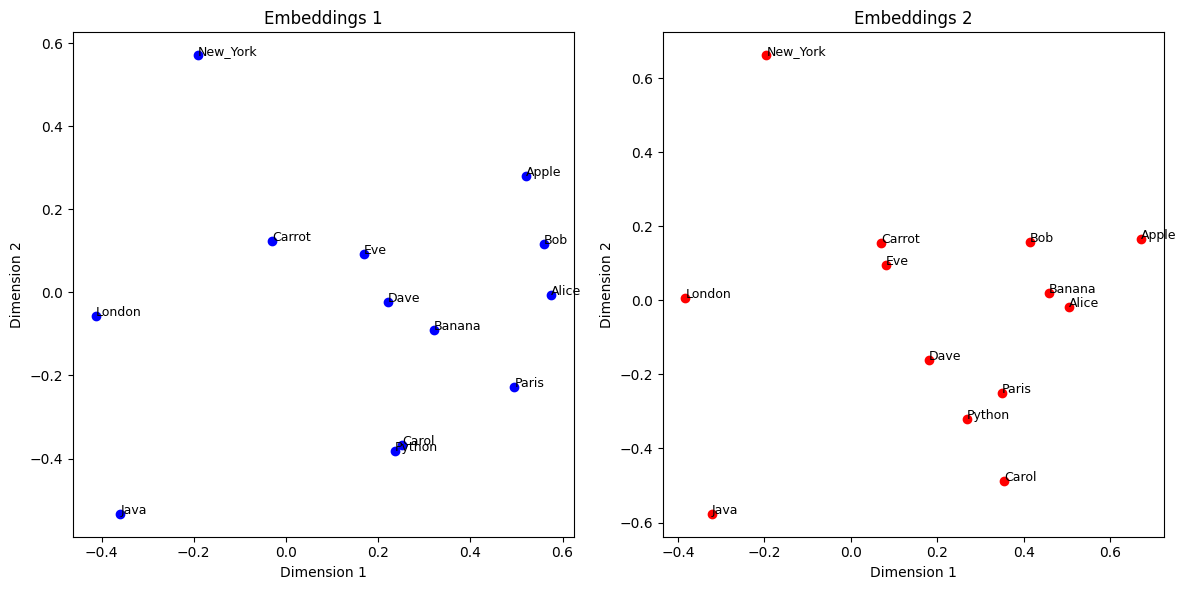

In [2]:
import matplotlib.pyplot as plt
import torch

# Define the embeddings and entity names
embeddings1 = torch.tensor([[ 0.5750, -0.0063],
                            [ 0.5590,  0.1171],
                            [ 0.2525, -0.3684],
                            [ 0.2217, -0.0240],
                            [ 0.1687,  0.0927],
                            [ 0.5213,  0.2792],
                            [ 0.3209, -0.0896],
                            [-0.0293,  0.1245],
                            [ 0.4956, -0.2268],
                            [-0.4130, -0.0562],
                            [-0.1914,  0.5708],
                            [ 0.2370, -0.3828],
                            [-0.3593, -0.5329]], device='cuda:0', requires_grad=True)

embeddings2 = torch.tensor([[ 0.5046, -0.0169],
                            [ 0.4143,  0.1563],
                            [ 0.3551, -0.4885],
                            [ 0.1813, -0.1621],
                            [ 0.0804,  0.0956],
                            [ 0.6713,  0.1663],
                            [ 0.4579,  0.0186],
                            [ 0.0709,  0.1540],
                            [ 0.3491, -0.2491],
                            [-0.3823,  0.0051],
                            [-0.1950,  0.6616],
                            [ 0.2692, -0.3194],
                            [-0.3210, -0.5763]], device='cuda:0', requires_grad=True)

entities = ["Alice", "Bob", "Carol", "Dave", "Eve", "Apple", "Banana", "Carrot", "Paris", "London", "New_York", "Python", "Java"]

# Convert embeddings to CPU for plotting
embeddings1 = embeddings1.cpu().detach().numpy()
embeddings2 = embeddings2.cpu().detach().numpy()

# Plot the embeddings
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot embeddings1
axes[0].scatter(embeddings1[:, 0], embeddings1[:, 1], color='blue')
for i, txt in enumerate(entities):
    axes[0].annotate(txt, (embeddings1[i, 0], embeddings1[i, 1]), fontsize=9)
axes[0].set_title('Embeddings 1')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')

# Plot embeddings2
axes[1].scatter(embeddings2[:, 0], embeddings2[:, 1], color='red')
for i, txt in enumerate(entities):
    axes[1].annotate(txt, (embeddings2[i, 0], embeddings2[i, 1]), fontsize=9)
axes[1].set_title('Embeddings 2')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')

plt.tight_layout()
plt.show()


In [1]:
import torch
import torch.nn as nn
from torch.autograd import Variable

# Assuming positive_scores and negative_scores are your input tensors
positive_scores = torch.tensor([0.2, 0.4, 0.6])
negative_scores = torch.tensor([-0.3, -0.1, 0.8])

# Calculate margin ranking loss
criterion = nn.MarginRankingLoss(margin=1.0)

# Create target tensor
num_samples = positive_scores.size(0)
target = torch.ones(num_samples, dtype=torch.float32)

# Calculate loss
loss = criterion(positive_scores, negative_scores, target)
print("Margin ranking loss:", loss.item())

Margin ranking loss: 0.7333333492279053


In [1]:
import numpy as np

# Entities
entities = {
    'cat': 0,
    'dog': 1,
    'animal': 2,
    'mouse': 3
}

# Relations
relations = {
    'chase': 0,
    'is_a': 1,
}

# Embeddings (2D)
embedding_size = 2
entity_embeddings = np.random.randn(len(entities), embedding_size)
relation_embeddings = np.random.randn(len(relations), embedding_size)

# Round the embeddings to two decimal places
entity_embeddings = np.round(entity_embeddings, 2)
relation_embeddings = np.round(relation_embeddings, 2)


# Triplets (subject, relation, object)
triplets = [
    ('cat', 'chase', 'mouse'),
    ('dog', 'chase', 'cat'),
    ('cat', 'is_a', 'animal'),
    ('dog', 'is_a', 'animal'),
]

# Hyperparameters
learning_rate = 0.01
margin = 1.0

def L2_norm(x):
    return np.sqrt(np.sum(np.square(x)))

def pairwise_hinge_loss(pos_score, neg_score, margin):
    return np.maximum(0, margin + pos_score - neg_score)

def update_embeddings(e_s, e_o, e_r, lr):
    return e_s - lr * (e_s - e_o - e_r)

# Training loop
epochs = 100
for epoch in range(epochs):
    total_loss = 0
    for (s, r, o) in triplets:
        s_id, r_id, o_id = entities[s], relations[r], entities[o]
        e_s, e_r, e_o = entity_embeddings[s_id], relation_embeddings[r_id], entity_embeddings[o_id]

        # Positive sample
        # we need this score to be small
        pos_score = L2_norm(e_s + e_r - e_o)

        # Corrupt object to create a negative sample
        o_neg_id = np.random.randint(0, len(entities))
        while (s_id, r_id, o_neg_id) in triplets:
            o_neg_id = np.random.randint(0, len(entities))
        e_o_neg = entity_embeddings[o_neg_id]
        neg_score = L2_norm(e_s + e_r - e_o_neg)

        loss = pairwise_hinge_loss(pos_score, neg_score, margin)
        total_loss += loss

        # Update embeddings
        if loss > 0:
            entity_embeddings[s_id] = update_embeddings(e_s, e_o, e_r, learning_rate)
            entity_embeddings[o_id] = update_embeddings(e_o, e_s, -e_r, learning_rate)
            entity_embeddings[o_neg_id] = update_embeddings(e_o_neg, e_s, -e_r, learning_rate)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss}")

# Example of querying
def query(subject, relation):
    s_id, r_id = entities[subject], relations[relation]
    e_s, e_r = entity_embeddings[s_id], relation_embeddings[r_id]
    scores = np.linalg.norm(entity_embeddings + e_r - e_s, axis=1)
    best_id = np.argsort(scores)[1]  # Exclude subject entity ( We need to remove Cat)
    for entity, entity_id in entities.items():
        if entity_id == best_id:
            return entity

# Example query
print(f"Most likely object chased by 'cat': {query('cat', 'chase')}")


Epoch 0, Loss: 2.8934537890273124
Epoch 10, Loss: 3.017535844267637
Epoch 20, Loss: 4.430539373215795
Epoch 30, Loss: 4.323004749923733
Epoch 40, Loss: 4.0686754398564595
Epoch 50, Loss: 5.9824295343955285
Epoch 60, Loss: 5.2334563269259
Epoch 70, Loss: 4.109809488009956
Epoch 80, Loss: 5.676995929530017
Epoch 90, Loss: 3.0598954997269256
Most likely object chased by 'cat': animal


In [ ]:

print(np.repeat([[1,2],[2,3]],1, axis=1))

In [ ]:
x = [i % 5 for i in range(15)]
print(x)

In [ ]:
a1 = np.array([[1,2],[3,4]])
a2 = np.array([[5,6],[7,8]])
np.column_stack((a1,a2))

In [ ]:

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print("CUDA available:", cuda_available)
# List all CUDA devices
if cuda_available:
    num_cuda_devices = torch.cuda.device_count()
    print("Number of CUDA devices:", num_cuda_devices)
    
    for i in range(num_cuda_devices):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [ ]:
import torch
import torch.nn as nn

# Set environment for better debugging
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

device = 'cpu'

# Define the number of entities and relations
num_entities = 4  # for Alice, Bob, Google, New York
num_relations = 2  # for works_at, lives_in

# Create embeddings
entities_embeddings = nn.Embedding(num_entities, 1).to(device)
relation_embeddings = nn.Embedding(num_relations, 1).to(device)

# Adjust indices for simplicity
entities = {
    'Alice': 0,
    'Bob': 1,
    'Google': 2,
    'New York': 3
}

relations = {
    'works_at': 0,
    'lives_in': 1
}

# Example triplets using proper indices
triplets = [
    (entities['Alice'], relations['lives_in'], entities['New York'])
]

# Convert list of tuples to a tensor
triplets_tensor = torch.tensor(triplets, dtype=torch.long, device=device)

# Extract head, relation, and tail indices
heads = triplets_tensor[:, 0]
relations = triplets_tensor[:, 1]
tails = triplets_tensor[:, 2]

# Fetch embeddings for heads, relations, and tails
head_embeddings = entities_embeddings(heads)
relation_embeddings = relation_embeddings(relations)
tail_embeddings = entities_embeddings(tails)

print("Head embeddings:", head_embeddings)
print("Relation embeddings:", relation_embeddings)
print("Tail embeddings:", tail_embeddings)


score = (head_embeddings + relation_embeddings) - tail_embeddings
# Default to l2 distance
score = torch.sqrt(torch.sum(score ** 2, dim=1))

print(score)